Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para ver mejor las tablas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("violencia_contra_la_mujer.csv")
df

,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD
0,2021,10,250102,UCAYALI,CORONEL PORTILLO,CAMPOVERDE,19
1,2023,7,130101,LA LIBERTAD,TRUJILLO,TRUJILLO,237
2,2024,10,190308,PASCO,OXAPAMPA,CONSTITUCION,9
3,2021,4,120903,JUNIN,CHUPACA,CHONGOS BAJO,1
4,2020,6,110109,ICA,ICA,SAN JOSE DE LOS MOLINOS,2
...,...,...,...,...,...,...,...
85636,2021,12,90713,HUANCAVELICA,TAYACAJA,QUISHUAR,4
85637,2022,1,131006,LA LIBERTAD,SANTIAGO DE CHUCO,QUIRUVILCA,3
85638,2023,3,20801,ANCASH,CASMA,CASMA,49
85639,2022,2,200108,PIURA,PIURA,EL TALLAN,1


In [2]:
# Limpiar nombres de columnas, por si aparece el símbolo raro BOM
df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()

df.head()

,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD
0,2021,10,250102,UCAYALI,CORONEL PORTILLO,CAMPOVERDE,19
1,2023,7,130101,LA LIBERTAD,TRUJILLO,TRUJILLO,237
2,2024,10,190308,PASCO,OXAPAMPA,CONSTITUCION,9
3,2021,4,120903,JUNIN,CHUPACA,CHONGOS BAJO,1
4,2020,6,110109,ICA,ICA,SAN JOSE DE LOS MOLINOS,2


In [3]:
print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nPrimeras filas:")
display(df.head())

print("\nÚltimas filas:")
display(df.tail())

Filas y columnas: (85641, 7)

Columnas:
['AÑO', 'MES', 'UBIGEO_HECHO', 'DPTO_HECHO', 'PROV_HECHO', 'DIST_HECHO', 'CANTIDAD']

Tipos de datos:
AÑO              int64
MES              int64
UBIGEO_HECHO     int64
DPTO_HECHO      object
PROV_HECHO      object
DIST_HECHO      object
CANTIDAD         int64
dtype: object

Primeras filas:


,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD
0,2021,10,250102,UCAYALI,CORONEL PORTILLO,CAMPOVERDE,19
1,2023,7,130101,LA LIBERTAD,TRUJILLO,TRUJILLO,237
2,2024,10,190308,PASCO,OXAPAMPA,CONSTITUCION,9
3,2021,4,120903,JUNIN,CHUPACA,CHONGOS BAJO,1
4,2020,6,110109,ICA,ICA,SAN JOSE DE LOS MOLINOS,2



Últimas filas:


,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD
85636,2021,12,90713,HUANCAVELICA,TAYACAJA,QUISHUAR,4
85637,2022,1,131006,LA LIBERTAD,SANTIAGO DE CHUCO,QUIRUVILCA,3
85638,2023,3,20801,ANCASH,CASMA,CASMA,49
85639,2022,2,200108,PIURA,PIURA,EL TALLAN,1
85640,2025,2,250107,UCAYALI,CORONEL PORTILLO,MANANTAY,16


In [4]:
print(f"La base tiene {df.shape[0]} registros y {df.shape[1]} variables.")
print("La unidad de análisis es un registro agregado de denuncias por UBIGEO, año y mes.")

La base tiene 85641 registros y 7 variables.
La unidad de análisis es un registro agregado de denuncias por UBIGEO, año y mes.


Diccionario de Variables

In [5]:
diccionario = pd.DataFrame({
    "Variable": df.columns,
    "Descripción": [
        "Año de registro de la denuncia",
        "Mes de registro de la denuncia",
        "Código UBIGEO del lugar del hecho",
        "Departamento donde ocurrió el hecho",
        "Provincia donde ocurrió el hecho",
        "Distrito donde ocurrió el hecho",
        "Cantidad de denuncias registradas"
    ],
    "Tipo esperado": [
        "Numérica discreta",
        "Numérica discreta",
        "Categórica / código territorial",
        "Categórica nominal",
        "Categórica nominal",
        "Categórica nominal",
        "Numérica discreta"
    ]
})

display(diccionario)

,Variable,Descripción,Tipo esperado
0,AÑO,Año de registro de la denuncia,Numérica discreta
1,MES,Mes de registro de la denuncia,Numérica discreta
2,UBIGEO_HECHO,Código UBIGEO del lugar del hecho,Categórica / código territorial
3,DPTO_HECHO,Departamento donde ocurrió el hecho,Categórica nominal
4,PROV_HECHO,Provincia donde ocurrió el hecho,Categórica nominal
5,DIST_HECHO,Distrito donde ocurrió el hecho,Categórica nominal
6,CANTIDAD,Cantidad de denuncias registradas,Numérica discreta


In [6]:
# Convertir UBIGEO a texto de 6 dígitos
df["UBIGEO_HECHO"] = df["UBIGEO_HECHO"].astype(str).str.zfill(6)

# Crear variables auxiliares
df["ANIO"] = df["AÑO"]
df["FECHA"] = pd.to_datetime(
    df["AÑO"].astype(str) + "-" + df["MES"].astype(str).str.zfill(2) + "-01"
)

# Extraer código de departamento, provincia y distrito desde UBIGEO
df["COD_DPTO"] = df["UBIGEO_HECHO"].str[:2]
df["COD_PROV"] = df["UBIGEO_HECHO"].str[:4]
df["COD_DIST"] = df["UBIGEO_HECHO"].str[:6]

df.head()

,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD,ANIO,FECHA,COD_DPTO,COD_PROV,COD_DIST
0,2021,10,250102,UCAYALI,CORONEL PORTILLO,CAMPOVERDE,19,2021,2021-10-01,25,2501,250102
1,2023,7,130101,LA LIBERTAD,TRUJILLO,TRUJILLO,237,2023,2023-07-01,13,1301,130101
2,2024,10,190308,PASCO,OXAPAMPA,CONSTITUCION,9,2024,2024-10-01,19,1903,190308
3,2021,4,120903,JUNIN,CHUPACA,CHONGOS BAJO,1,2021,2021-04-01,12,1209,120903
4,2020,6,110109,ICA,ICA,SAN JOSE DE LOS MOLINOS,2,2020,2020-06-01,11,1101,110109


In [7]:
# Valores faltantes
faltantes = df.isna().sum().reset_index()
faltantes.columns = ["Variable", "Cantidad_faltantes"]
faltantes["Porcentaje_faltantes"] = (faltantes["Cantidad_faltantes"] / len(df)) * 100
display(faltantes.sort_values("Porcentaje_faltantes", ascending=False))

# Duplicados exactos
duplicados = df.duplicated().sum()
print("Duplicados exactos:", duplicados)

# Registros con cantidad menor o igual a 0
cantidad_invalida = df[df["CANTIDAD"] <= 0]
print("Registros con CANTIDAD <= 0:", len(cantidad_invalida))

# Meses fuera de rango
meses_invalidos = df[(df["MES"] < 1) | (df["MES"] > 12)]
print("Registros con mes inválido:", len(meses_invalidos))

# Años disponibles
print("Años disponibles:", sorted(df["AÑO"].unique()))

,Variable,Cantidad_faltantes,Porcentaje_faltantes
0,AÑO,0,0.0
1,MES,0,0.0
2,UBIGEO_HECHO,0,0.0
3,DPTO_HECHO,0,0.0
4,PROV_HECHO,0,0.0
5,DIST_HECHO,0,0.0
6,CANTIDAD,0,0.0
7,ANIO,0,0.0
8,FECHA,0,0.0
9,COD_DPTO,0,0.0


Duplicados exactos: 0
Registros con CANTIDAD <= 0: 0
Registros con mes inválido: 0
Años disponibles: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [8]:
display(df.describe(include="all"))

print("Total de denuncias registradas:", df["CANTIDAD"].sum())
print("Promedio de denuncias por registro:", df["CANTIDAD"].mean())
print("Mediana de denuncias por registro:", df["CANTIDAD"].median())
print("Máximo de denuncias en un registro:", df["CANTIDAD"].max())

,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD,ANIO,FECHA,COD_DPTO,COD_PROV,COD_DIST
count,85641.000000,85641.000000,85641,85641,85641,85641,85641.000000,85641.000000,85641,85641,85641,85641
unique,NaN,NaN,1799,26,195,1649,NaN,NaN,NaN,25,196,1799
top,NaN,NaN,250102,CUSCO,LIMA,SANTA ROSA,NaN,NaN,NaN,15,1501,250102
freq,NaN,NaN,93,6965,3962,418,NaN,NaN,NaN,8370,3962,93
mean,2021.539193,6.430273,NaN,NaN,NaN,NaN,22.978211,2021.539193,2021-12-28 03:30:44.074683904,NaN,NaN,NaN
min,2018.000000,1.000000,NaN,NaN,NaN,NaN,1.000000,2018.000000,2018-01-01 00:00:00,NaN,NaN,NaN
25%,2020.000000,3.000000,NaN,NaN,NaN,NaN,2.000000,2020.000000,2020-03-01 00:00:00,NaN,NaN,NaN
50%,2022.000000,6.000000,NaN,NaN,NaN,NaN,4.000000,2022.000000,2022-01-01 00:00:00,NaN,NaN,NaN
75%,2023.000000,9.000000,NaN,NaN,NaN,NaN,16.000000,2023.000000,2023-11-01 00:00:00,NaN,NaN,NaN
max,2025.000000,12.000000,NaN,NaN,NaN,NaN,1302.000000,2025.000000,2025-09-01 00:00:00,NaN,NaN,NaN


Total de denuncias registradas: 1967877
Promedio de denuncias por registro: 22.97821137072197
Mediana de denuncias por registro: 4.0
Máximo de denuncias en un registro: 1302


In [9]:
# Asegurar UBIGEO como texto de 6 dígitos
df["UBIGEO_HECHO"] = df["UBIGEO_HECHO"].astype(str).str.zfill(6)

# Mínimo y máximo de la variable CANTIDAD
min_cantidad = df["CANTIDAD"].min()
max_cantidad = df["CANTIDAD"].max()

print("Mínimo de CANTIDAD:", min_cantidad)
print("Máximo de CANTIDAD:", max_cantidad)

# Filas completas donde aparece el mínimo
registros_min = df[df["CANTIDAD"] == min_cantidad].copy()

# Filas completas donde aparece el máximo
registros_max = df[df["CANTIDAD"] == max_cantidad].copy()

print("\nCantidad de registros con el valor mínimo:", registros_min.shape[0])
print("Cantidad de registros con el valor máximo:", registros_max.shape[0])

print("\nRegistro(s) con el valor máximo:")
display(registros_max)

print("\nPrimeros registros con el valor mínimo:")
display(registros_min.head(20))

Mínimo de CANTIDAD: 1
Máximo de CANTIDAD: 1302

Cantidad de registros con el valor mínimo: 21189
Cantidad de registros con el valor máximo: 1

Registro(s) con el valor máximo:


,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD,ANIO,FECHA,COD_DPTO,COD_PROV,COD_DIST
75739,2020,1,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1302,2020,2020-01-01,15,1501,150132



Primeros registros con el valor mínimo:


,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD,ANIO,FECHA,COD_DPTO,COD_PROV,COD_DIST
3,2021,4,120903,JUNIN,CHUPACA,CHONGOS BAJO,1,2021,2021-04-01,12,1209,120903
5,2025,2,010504,AMAZONAS,LUYA,COLCAMAR,1,2025,2025-02-01,01,0105,010504
6,2024,8,160604,LORETO,UCAYALI,PAMPA HERMOSA,1,2024,2024-08-01,16,1606,160604
18,2022,6,040413,AREQUIPA,CASTILLA,URACA,1,2022,2022-06-01,04,0404,040413
22,2024,1,010520,AMAZONAS,LUYA,SANTA CATALINA,1,2024,2024-01-01,01,0105,010520
30,2025,7,030306,APURIMAC,ANTABAMBA,PACHACONAS,1,2025,2025-07-01,03,0303,030306
34,2021,3,021012,ANCASH,HUARI,RAHUAPAMPA,1,2021,2021-03-01,02,0210,021012
42,2020,11,070105,PROV. CONST. DEL CALLAO,CALLAO,LA PUNTA,1,2020,2020-11-01,07,0701,070105
43,2019,5,200502,PIURA,PAITA,AMOTAPE,1,2019,2019-05-01,20,2005,200502
53,2021,1,050505,AYACUCHO,LA MAR,CHUNGUI,1,2021,2021-01-01,05,0505,050505


Distribución de la variable CANTIDAD

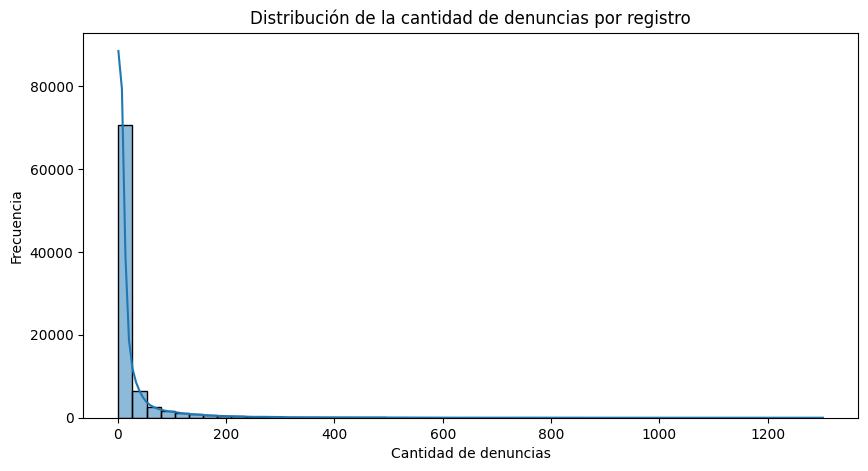

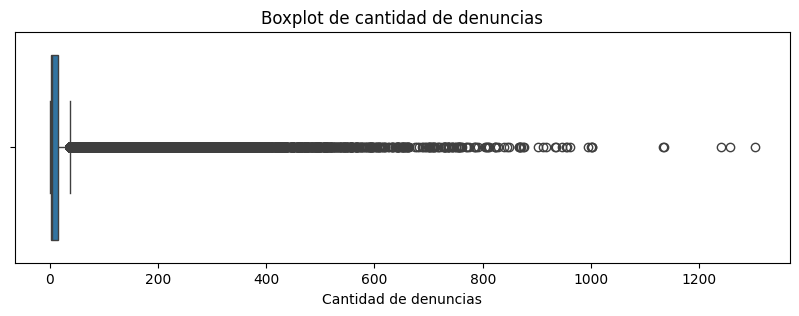

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df["CANTIDAD"], bins=50, kde=True)
plt.title("Distribución de la cantidad de denuncias por registro")
plt.xlabel("Cantidad de denuncias")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=df["CANTIDAD"])
plt.title("Boxplot de cantidad de denuncias")
plt.xlabel("Cantidad de denuncias")
plt.show()

Como está sesgada a la derecha, se usa también escala logarítmica:

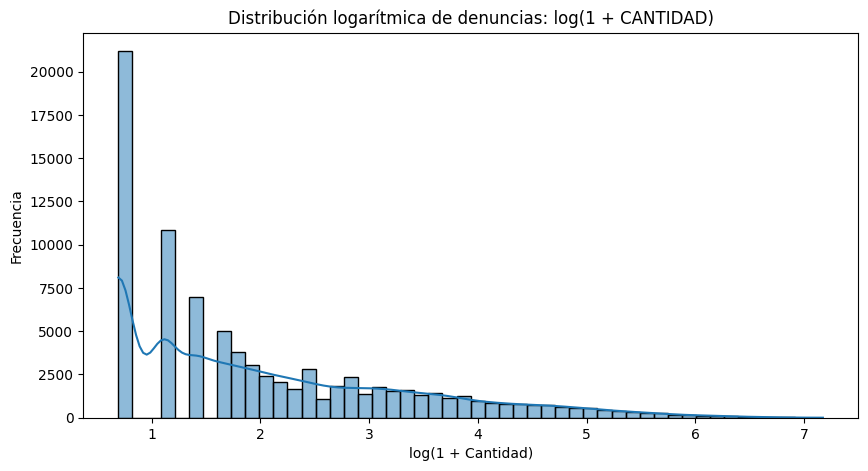

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df["CANTIDAD"]), bins=50, kde=True)
plt.title("Distribución logarítmica de denuncias: log(1 + CANTIDAD)")
plt.xlabel("log(1 + Cantidad)")
plt.ylabel("Frecuencia")
plt.show()

In [13]:
Q1 = df["CANTIDAD"].quantile(0.25)
Q3 = df["CANTIDAD"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[df["CANTIDAD"] > limite_superior]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite superior:", limite_superior)
print("Cantidad de outliers:", len(outliers))
print("Porcentaje de outliers:", round(len(outliers) / len(df) * 100, 2), "%")

display(outliers.sort_values("CANTIDAD", ascending=False).head(20))

Q1: 2.0
Q3: 16.0
IQR: 14.0
Límite superior: 37.0
Cantidad de outliers: 11747
Porcentaje de outliers: 13.72 %


,AÑO,MES,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD,ANIO,FECHA,COD_DPTO,COD_PROV,COD_DIST
75739,2020,1,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1302,2020,2020-01-01,15,1501,150132
80802,2019,3,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1257,2019,2019-03-01,15,1501,150132
67952,2020,2,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1240,2020,2020-02-01,15,1501,150132
17653,2019,1,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1134,2019,2019-01-01,15,1501,150132
81138,2019,2,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1133,2019,2019-02-01,15,1501,150132
29352,2023,3,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1001,2023,2023-03-01,15,1501,150132
44749,2018,12,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1001,2018,2018-12-01,15,1501,150132
62838,2019,4,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,1000,2019,2019-04-01,15,1501,150132
3167,2022,3,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,995,2022,2022-03-01,15,1501,150132
25773,2021,1,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,961,2021,2021-01-01,15,1501,150132


* Los outliers no necesariamente son errores; pueden representar distritos con alta concentración de denuncias.
* Por eso no se debe eliminar, sino analizarlos territorialmente.

Grafico para las denuncias por año

,AÑO,CANTIDAD
0,2018,250515
1,2019,296964
2,2020,250348
3,2021,258060
4,2022,247403
5,2023,256184
6,2024,243863
7,2025,164540


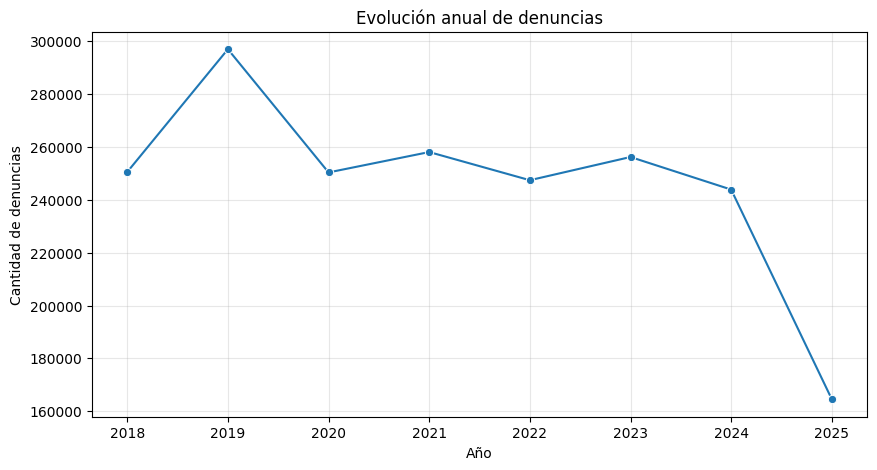

In [14]:
denuncias_anio = df.groupby("AÑO", as_index=False)["CANTIDAD"].sum()

display(denuncias_anio)

plt.figure(figsize=(10,5))
sns.lineplot(data=denuncias_anio, x="AÑO", y="CANTIDAD", marker="o")
plt.title("Evolución anual de denuncias")
plt.xlabel("Año")
plt.ylabel("Cantidad de denuncias")
plt.grid(True, alpha=0.3)
plt.show()

Grafico de Denuncias por mes

,MES,CANTIDAD
0,1,188323
1,2,177003
2,3,182697
3,4,158082
4,5,159166
5,6,156225
6,7,159276
7,8,160768
8,9,161823
9,10,152286


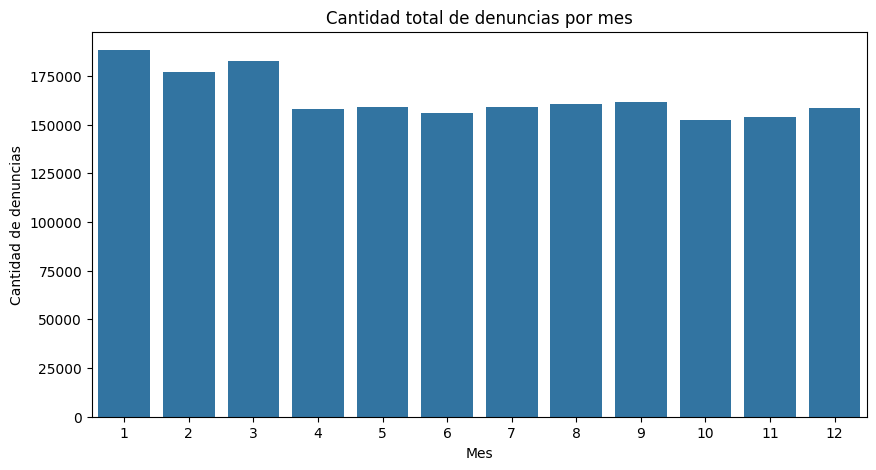

In [15]:
denuncias_mes = df.groupby("MES", as_index=False)["CANTIDAD"].sum()

display(denuncias_mes)

plt.figure(figsize=(10,5))
sns.barplot(data=denuncias_mes, x="MES", y="CANTIDAD")
plt.title("Cantidad total de denuncias por mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad de denuncias")
plt.show()

,FECHA,CANTIDAD
0,2018-01-01,19186
1,2018-02-01,18958
2,2018-03-01,21015
3,2018-04-01,20773
4,2018-05-01,20449


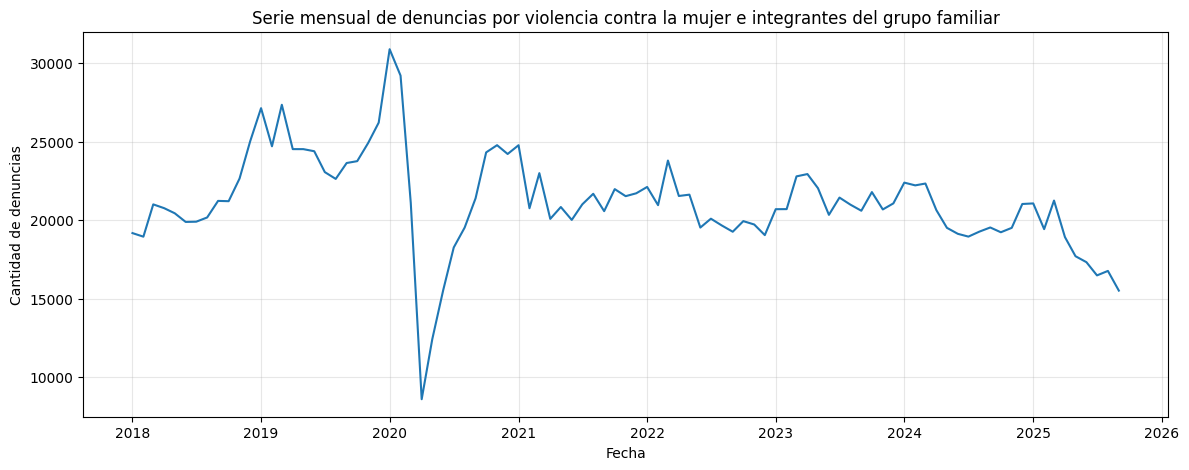

In [16]:
serie_mensual = df.groupby("FECHA", as_index=False)["CANTIDAD"].sum()

display(serie_mensual.head())

plt.figure(figsize=(14,5))
sns.lineplot(data=serie_mensual, x="FECHA", y="CANTIDAD")
plt.title("Serie mensual de denuncias por violencia contra la mujer e integrantes del grupo familiar")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de denuncias")
plt.grid(True, alpha=0.3)
plt.show()

Ranking por departamento

,DPTO_HECHO,CANTIDAD
13,LIMA METROPOLITANA,632795
3,AREQUIPA,149048
18,PIURA,101078
6,CUSCO,97197
10,JUNIN,88327
12,LAMBAYEQUE,88238
11,LA LIBERTAD,84629
19,PROV. CONST. DEL CALLAO,79431
1,ANCASH,75798
9,ICA,71966


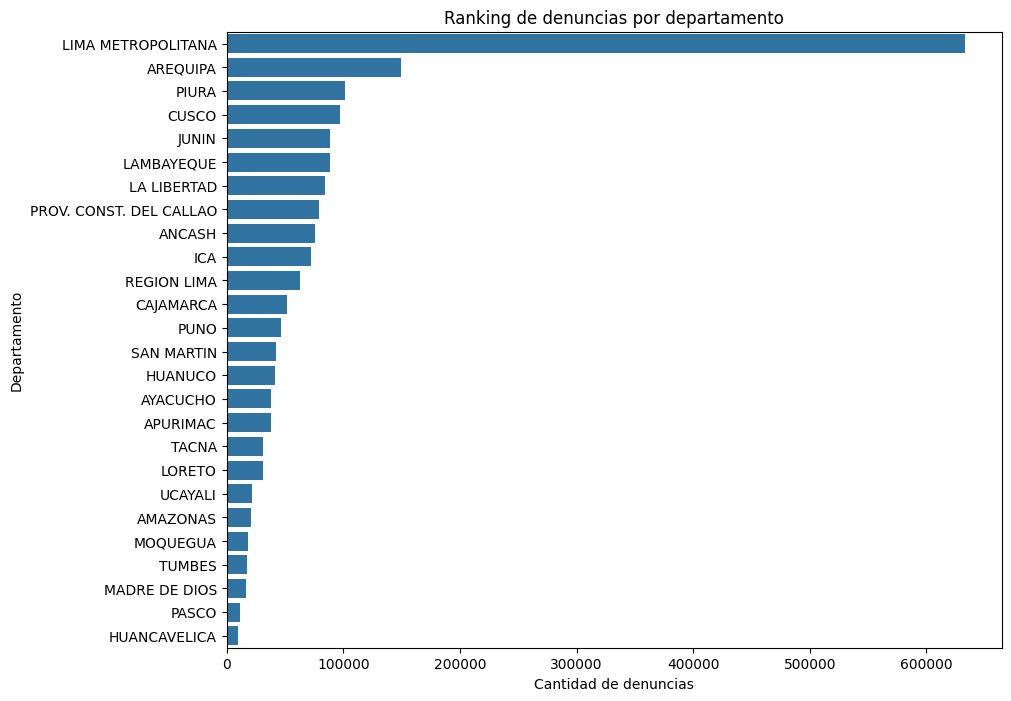

In [17]:
denuncias_dpto = (
    df.groupby("DPTO_HECHO", as_index=False)["CANTIDAD"]
    .sum()
    .sort_values("CANTIDAD", ascending=False)
)

display(denuncias_dpto)

plt.figure(figsize=(10,8))
sns.barplot(
    data=denuncias_dpto,
    y="DPTO_HECHO",
    x="CANTIDAD"
)
plt.title("Ranking de denuncias por departamento")
plt.xlabel("Cantidad de denuncias")
plt.ylabel("Departamento")
plt.show()

TOP de 20 Distritos con más denuncias

,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD
1262,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,71999
1231,150101,LIMA METROPOLITANA,LIMA,LIMA,47465
663,070101,PROV. CONST. DEL CALLAO,CALLAO,CALLAO,46902
1240,150110,LIMA METROPOLITANA,LIMA,COMAS,45192
1233,150103,LIMA METROPOLITANA,LIMA,ATE,42331
1265,150135,LIMA METROPOLITANA,LIMA,SAN MARTIN DE PORRES,33497
1273,150143,LIMA METROPOLITANA,LIMA,VILLA MARIA DEL TRIUNFO,32669
1247,150117,LIMA METROPOLITANA,LIMA,LOS OLIVOS,29577
1236,150106,LIMA METROPOLITANA,LIMA,CARABAYLLO,28658
1272,150142,LIMA METROPOLITANA,LIMA,VILLA EL SALVADOR,28483


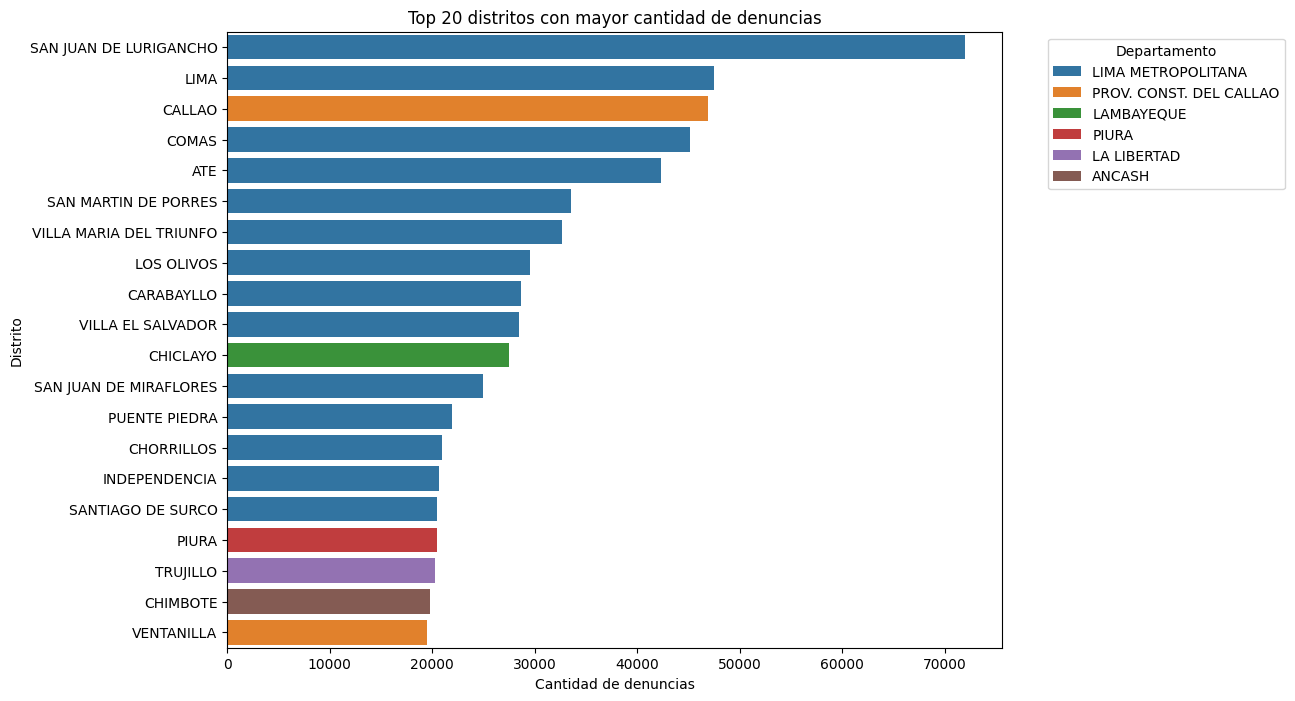

In [18]:
denuncias_distrito = (
    df.groupby(["UBIGEO_HECHO", "DPTO_HECHO", "PROV_HECHO", "DIST_HECHO"], as_index=False)["CANTIDAD"]
    .sum()
    .sort_values("CANTIDAD", ascending=False)
)

top20_distritos = denuncias_distrito.head(20)
display(top20_distritos)

plt.figure(figsize=(10,8))
sns.barplot(
    data=top20_distritos,
    y="DIST_HECHO",
    x="CANTIDAD",
    hue="DPTO_HECHO",
    dodge=False
)
plt.title("Top 20 distritos con mayor cantidad de denuncias")
plt.xlabel("Cantidad de denuncias")
plt.ylabel("Distrito")
plt.legend(title="Departamento", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Mapa de calor año vs mes

MES,1,2,3,4,5,6,7,8,9,10,11,12
AÑO,,,,,,,,,,,,
2018,19186,18958,21015,20773,20449,19897,19912,20181,21237,21218,22663,25026
2019,27144,24715,27360,24535,24534,24401,23071,22637,23650,23769,24924,26224
2020,30899,29219,21110,8603,12422,15544,18270,19538,21405,24327,24786,24225
2021,24784,20769,23005,20092,20847,20025,21019,21690,20583,21987,21538,21721
2022,22125,20965,23807,21550,21635,19538,20103,19670,19272,19948,19733,19057
2023,20708,20713,22799,22946,22045,20348,21448,20998,20610,21798,20692,21079
2024,22401,22226,22343,20650,19521,19139,18962,19278,19544,19239,19520,21040
2025,21076,19438,21258,18933,17713,17333,16491,16776,15522,0,0,0


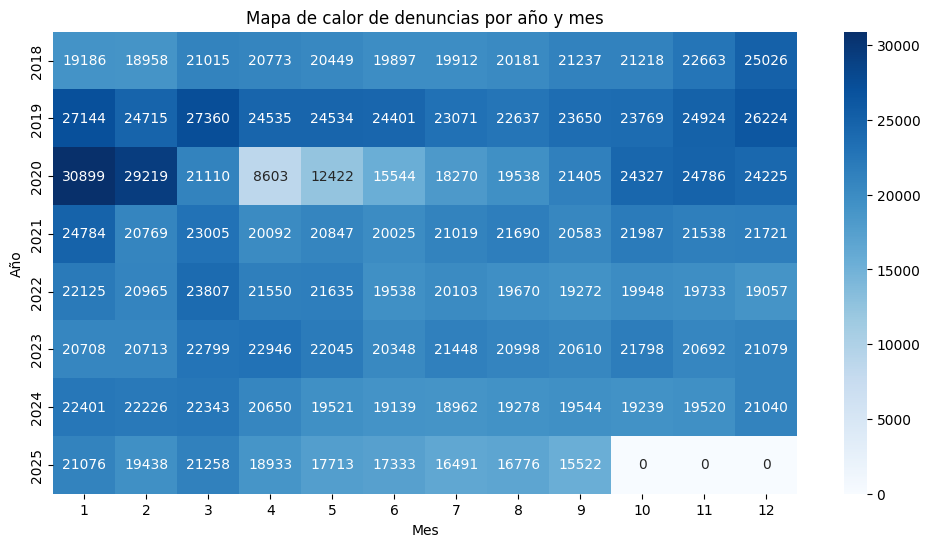

In [19]:
tabla_anio_mes = df.pivot_table(
    index="AÑO",
    columns="MES",
    values="CANTIDAD",
    aggfunc="sum",
    fill_value=0
)

display(tabla_anio_mes)

plt.figure(figsize=(12,6))
sns.heatmap(tabla_anio_mes, annot=True, fmt=".0f", cmap="Blues")
plt.title("Mapa de calor de denuncias por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.show()

Relacion entre número de distritos y denuncias por departamento

,DPTO_HECHO,TOTAL_DENUNCIAS,NUM_DISTRITOS,PROMEDIO_DENUNCIAS_REGISTRO
13,LIMA METROPOLITANA,632795,43,159.716052
3,AREQUIPA,149048,108,25.374191
18,PIURA,101078,65,22.863153
6,CUSCO,97197,110,13.955061
10,JUNIN,88327,123,14.350447
12,LAMBAYEQUE,88238,38,27.774001
11,LA LIBERTAD,84629,79,20.676521
19,PROV. CONST. DEL CALLAO,79431,7,125.681962
1,ANCASH,75798,157,13.706691
9,ICA,71966,43,22.588198


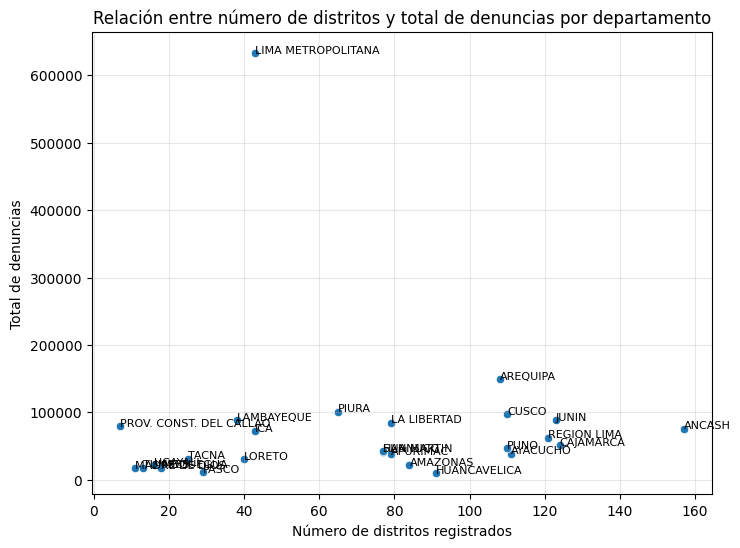

In [20]:
relacion_dpto = df.groupby("DPTO_HECHO").agg(
    TOTAL_DENUNCIAS=("CANTIDAD", "sum"),
    NUM_DISTRITOS=("UBIGEO_HECHO", "nunique"),
    PROMEDIO_DENUNCIAS_REGISTRO=("CANTIDAD", "mean")
).reset_index()

display(relacion_dpto.sort_values("TOTAL_DENUNCIAS", ascending=False))

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=relacion_dpto,
    x="NUM_DISTRITOS",
    y="TOTAL_DENUNCIAS"
)

for i, row in relacion_dpto.iterrows():
    plt.text(row["NUM_DISTRITOS"], row["TOTAL_DENUNCIAS"], row["DPTO_HECHO"], fontsize=8)

plt.title("Relación entre número de distritos y total de denuncias por departamento")
plt.xlabel("Número de distritos registrados")
plt.ylabel("Total de denuncias")
plt.grid(True, alpha=0.3)
plt.show()